# In this Notebook we attempt to find the best model
We compare the logistic regression, decision Trees and random forest model to find the best model for predicition of occupancy.
- we later also tune the models and then compare the performance of the models after tuning them to get the best performance

In [1]:
# ===============================================
# BASIC SETUP: GIT Auth and mounting google drive
# ================================================

from google.colab import drive
import sys

# Standard mount to access the config file initially
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Group 1/Room-Occupancy-Detection/src')

from utils.config import initialize_project
initialize_project()

Mounted at /content/drive
Authenticated as: Ande404
Working Directory: /content/drive/.shortcut-targets-by-id/1yYMYQP42V95jrAfCLhvSv1wAR0w7j8iP/Big-data-group-1/Room-Occupancy-Detection


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
train_df = pd.read_csv("data/raw/datatraining.txt")
test1_df = pd.read_csv("data/raw/datatest.txt")
test2_df = pd.read_csv("data/raw/datatest2.txt")

In [4]:
print("Train shape:", train_df.shape)
print("Test1 shape:", test1_df.shape)
print("Test2 shape:", test2_df.shape)

Train shape: (8143, 7)
Test1 shape: (2665, 7)
Test2 shape: (9752, 7)


In [7]:
features = ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]
target = "Occupancy"

X_train = train_df[features]
y_train = train_df[target]

X_test1 = test1_df[features]
y_test1 = test1_df[target]

X_test2 = test2_df[features]
y_test2 = test2_df[target]

In [5]:
# evaluation function
def evaluate_model(model_name, y_true, y_pred):
    print(f"--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1 Score:", round(f1_score(y_true, y_pred), 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [8]:
# scaling the logistic regression features
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

--- Logistic Regression - Test1 ---
Accuracy: 0.9771
Precision: 0.947
Recall: 0.9928
F1 Score: 0.9694

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1693
           1       0.95      0.99      0.97       972

    accuracy                           0.98      2665
   macro avg       0.97      0.98      0.98      2665
weighted avg       0.98      0.98      0.98      2665



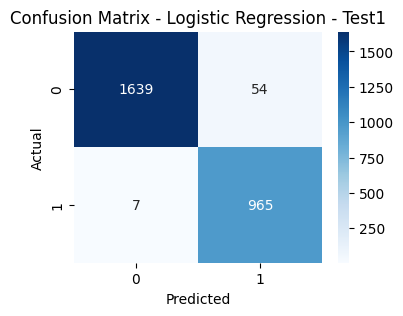

--- Logistic Regression - Test2 ---
Accuracy: 0.9851
Precision: 0.9741
Recall: 0.9546
F1 Score: 0.9643

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7703
           1       0.97      0.95      0.96      2049

    accuracy                           0.99      9752
   macro avg       0.98      0.97      0.98      9752
weighted avg       0.99      0.99      0.99      9752



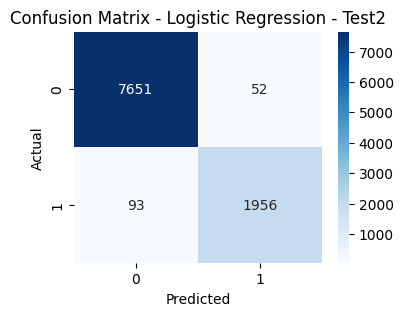

In [9]:
lr_pred_test1 = lr_pipeline.predict(X_test1)
lr_pred_test2 = lr_pipeline.predict(X_test2)

evaluate_model("Logistic Regression - Test1", y_test1, lr_pred_test1)
evaluate_model("Logistic Regression - Test2", y_test2, lr_pred_test2)

In [10]:
# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

--- Random Forest - Test1 ---
Accuracy: 0.9535
Precision: 0.9444
Recall: 0.927
F1 Score: 0.9356

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1693
           1       0.94      0.93      0.94       972

    accuracy                           0.95      2665
   macro avg       0.95      0.95      0.95      2665
weighted avg       0.95      0.95      0.95      2665



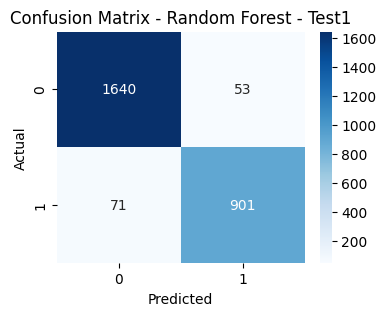

--- Random Forest - Test2 ---
Accuracy: 0.9722
Precision: 0.8855
Recall: 0.9966
F1 Score: 0.9378

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      7703
           1       0.89      1.00      0.94      2049

    accuracy                           0.97      9752
   macro avg       0.94      0.98      0.96      9752
weighted avg       0.98      0.97      0.97      9752



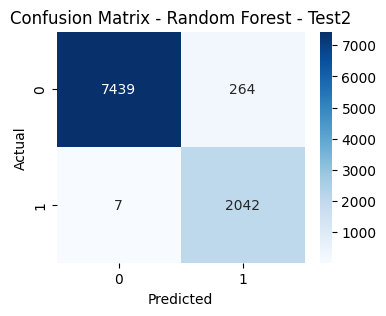

In [11]:
rf_pred_test1 = rf_model.predict(X_test1)
rf_pred_test2 = rf_model.predict(X_test2)

evaluate_model("Random Forest - Test1", y_test1, rf_pred_test1)
evaluate_model("Random Forest - Test2", y_test2, rf_pred_test2)

In [12]:
# Basic Decision Tree Model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

--- Decision Tree - Test1 ---
Accuracy: 0.7842
Precision: 0.9344
Recall: 0.4393
F1 Score: 0.5976

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.98      0.85      1693
           1       0.93      0.44      0.60       972

    accuracy                           0.78      2665
   macro avg       0.84      0.71      0.73      2665
weighted avg       0.82      0.78      0.76      2665



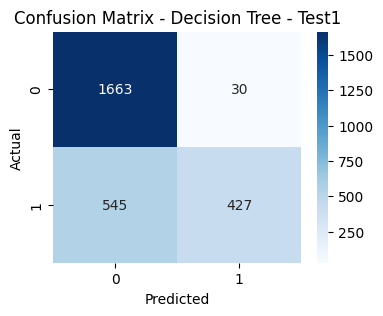

--- Decision Tree - Test2 ---
Accuracy: 0.9353
Precision: 0.8489
Recall: 0.8419
F1 Score: 0.8454

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7703
           1       0.85      0.84      0.85      2049

    accuracy                           0.94      9752
   macro avg       0.90      0.90      0.90      9752
weighted avg       0.94      0.94      0.94      9752



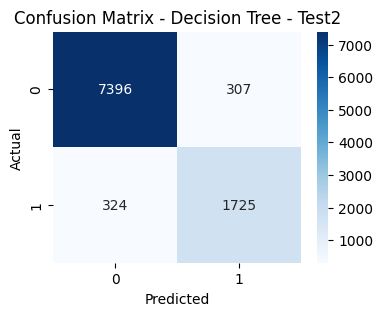

In [13]:
dt_pred_test1 = dt_model.predict(X_test1)
dt_pred_test2 = dt_model.predict(X_test2)

evaluate_model("Decision Tree - Test1", y_test1, dt_pred_test1)
evaluate_model("Decision Tree - Test2", y_test2, dt_pred_test2)

In [14]:
# model comparison table
results = []

def add_result(model_name, dataset_name, y_true, y_pred):
    results.append({
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    })

add_result("Logistic Regression", "Test1", y_test1, lr_pred_test1)
add_result("Logistic Regression", "Test2", y_test2, lr_pred_test2)

add_result("Decision Tree", "Test1", y_test1, dt_pred_test1)
add_result("Decision Tree", "Test2", y_test2, dt_pred_test2)

add_result("Random Forest", "Test1", y_test1, rf_pred_test1)
add_result("Random Forest", "Test2", y_test2, rf_pred_test2)

results_df = pd.DataFrame(results)
results_df

,Model,Dataset,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Test1,0.977111,0.947007,0.992798,0.969362
1,Logistic Regression,Test2,0.985131,0.974104,0.954612,0.964259
2,Decision Tree,Test1,0.784240,0.934354,0.439300,0.597621
3,Decision Tree,Test2,0.935295,0.848917,0.841874,0.845381
4,Random Forest,Test1,0.953471,0.944444,0.926955,0.935618
5,Random Forest,Test2,0.972211,0.885516,0.996584,0.937773


In [15]:
# sort values
results_df.sort_values(by=["Dataset", "F1 Score"], ascending=False)

,Model,Dataset,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,Test2,0.985131,0.974104,0.954612,0.964259
5,Random Forest,Test2,0.972211,0.885516,0.996584,0.937773
3,Decision Tree,Test2,0.935295,0.848917,0.841874,0.845381
0,Logistic Regression,Test1,0.977111,0.947007,0.992798,0.969362
4,Random Forest,Test1,0.953471,0.944444,0.926955,0.935618
2,Decision Tree,Test1,0.784240,0.934354,0.439300,0.597621


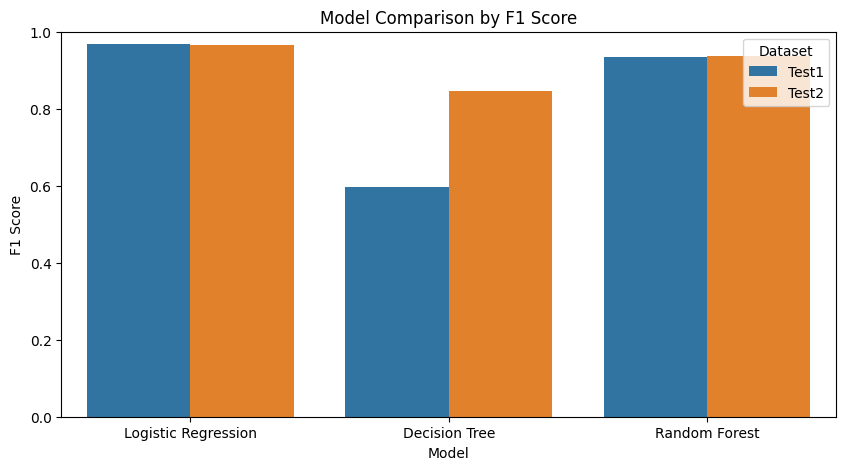

In [16]:
# plot model comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="F1 Score", hue="Dataset")
plt.title("Model Comparison by F1 Score")
plt.ylim(0, 1)
plt.show()

In [17]:
# Logistic regression coefficients
lr_model = lr_pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
2,Light,3.909408
3,CO2,1.896737
1,Humidity,0.026633
4,HumidityRatio,-0.233294
0,Temperature,-1.302526


In [18]:
# Random forest coefficients
rf_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance_df

,Feature,Importance
2,Light,0.597703
3,CO2,0.247182
0,Temperature,0.095599
4,HumidityRatio,0.032384
1,Humidity,0.027132


In [22]:
# We are trying to find the best hyperparameters that produce the highest results for the Random forest model
depths = [3, 5, 10, None]

for d in depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)

    pred = rf.predict(X_test2)
    print(f"Depth {d} → F1:", f1_score(y_test2, pred))

Depth 3 → F1: 0.9835828102366007
Depth 5 → F1: 0.978651954905253
Depth 10 → F1: 0.9369121358109658
Depth None → F1: 0.937772675086108


Best params: {'model__C': 0.1, 'model__penalty': 'l2'}
--- Tuned Logistic Regression - Test1 ---
Accuracy: 0.9786
Precision: 0.9472
Recall: 0.9969
F1 Score: 0.9714

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1693
           1       0.95      1.00      0.97       972

    accuracy                           0.98      2665
   macro avg       0.97      0.98      0.98      2665
weighted avg       0.98      0.98      0.98      2665



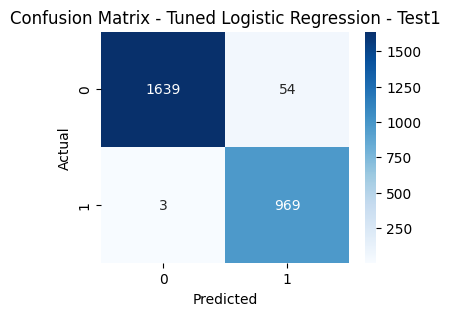

--- Tuned Logistic Regression - Test2 ---
Accuracy: 0.9928
Precision: 0.9732
Recall: 0.9932
F1 Score: 0.9831

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      7703
           1       0.97      0.99      0.98      2049

    accuracy                           0.99      9752
   macro avg       0.99      0.99      0.99      9752
weighted avg       0.99      0.99      0.99      9752



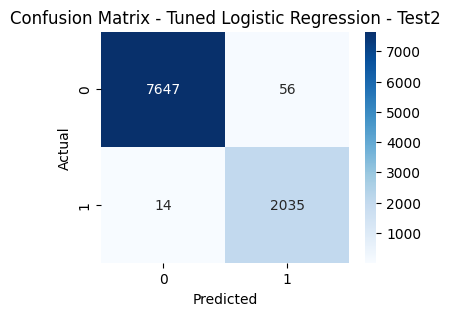

In [24]:
# we are trying to find the best hyperparameters for the logsitic regression model by using regularization
# this will produce the best tuned logistic regression model
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"]  # keep it simple for now
}
grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

best_lr_model = grid.best_estimator_
lr_pred_test1 = best_lr_model.predict(X_test1)
lr_pred_test2 = best_lr_model.predict(X_test2)
evaluate_model("Tuned Logistic Regression - Test1", y_test1, lr_pred_test1)
evaluate_model("Tuned Logistic Regression - Test2", y_test2, lr_pred_test2)

After hyperparameter tuning, both Logistic Regression and Random Forest achieved near-identical performance. This indicates that the underlying relationship between environmental features and occupancy is predominantly linear, with limited nonlinear complexity.


# Final Takeaway
The optimal regularization strength suggests that a simpler linear model generalizes best, reinforcing that the signal in the data is strong and not overly complex.